<a href="https://colab.research.google.com/github/ralucamicu/FineTuning-LLMs-for-Cybersecurity-Knowledge/blob/master/finetune_gemma_mitre_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning Gemma for MITRE ATT&CK Security Event Classification


## 1. Environment Setup

In [1]:
import torch
assert torch.cuda.is_available(), "No GPU detected. Runtime → Change runtime type → T4 GPU."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}")
print(f"VRAM: {gpu.total_memory / 1024**3:.1f} GB")

GPU: Tesla T4
VRAM: 14.6 GB


In [1]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Uninstall existing unsloth and related packages to ensure a clean install
    !pip uninstall -y unsloth unsloth-zoo peft trl transformers torchao bitsandbytes accelerate xformers
    # Use unsloth's recommended installation for Colab with CUDA 12.x
    # This will install compatible versions of unsloth, bitsandbytes, accelerate, xformers, peft, trl, triton.
    # We specify cu121 as the closest supported CUDA version for 12.8 in unsloth.
    !pip install "unsloth[cu121] @ git+https://github.com/unslothai/unsloth.git"
    # Install other non-conflicting dependencies if not handled by unsloth's extras
    !pip install sentencepiece protobuf "datasets==3.4.1" huggingface_hub hf_transfer
    # Ensure torchao is at a compatible version as required by peft
    # Unsloth's install should ideally handle this, but explicit upgrade is a safeguard.
    !pip install --upgrade torchao
!pip install -qU scikit-learn pandas matplotlib seaborn

In [3]:
import json, re, random, gc
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
from sklearn.model_selection import train_test_split

random.seed(3407)
np.random.seed(3407)
torch.manual_seed(3407)
print("Setup complete.")

Setup complete.


## 2. Load the Security Event Dataset

In [4]:
!rm -rf /content/AI-driven-MITRE-Attack
!git clone --depth=1 https://github.com/mouna23/AI-driven-MITRE-Attack.git /content/AI-driven-MITRE-Attack
!ls /content/AI-driven-MITRE-Attack/data/

Cloning into '/content/AI-driven-MITRE-Attack'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 0), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 6.81 MiB | 10.39 MiB/s, done.
dataset_full_160k.csv  readme.md


In [5]:
DATA_PATH = "/content/AI-driven-MITRE-Attack/data/dataset_full_160k.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Total samples: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst row:")
print(df.iloc[0])

Total samples: 160,000

Columns: ['timestamp', 'host', 'user', 'parent_process', 'commandline', 'process_name', 'source_ip', 'dest_ip', 'file_hash', 'raw_message', 'event_type', 'mitre_label', 'mitre_name']

First row:
timestamp                               2025-11-14T02:03:35.943650Z
host                                                      host-0132
user                                                           john
parent_process                                         explorer.exe
commandline       powershell -c "New-Object System.Net.Sockets.T...
process_name                                             powershell
source_ip                                                10.0.5.193
dest_ip                                                52.112.5.123
file_hash         8f747301679cbb103ca72bc7fdd1aca81ea93b51b73848...
raw_message       powershell -c "New-Object System.Net.Sockets.T...
event_type                                                   Sysmon
mitre_label                      

In [6]:
print("Top 15 MITRE techniques by frequency (name):")
print(df['mitre_name'].value_counts().head(15))
print(f"\nTotal unique mitre_name values:  {df['mitre_name'].nunique()}")
print(f"Total unique mitre_label values: {df['mitre_label'].nunique()}")

id_per_name = df.groupby('mitre_name')['mitre_label'].nunique()
collisions = id_per_name[id_per_name > 1]
if len(collisions) > 0:
    print(f"\nNote: {len(collisions)} names map to multiple IDs (collapsed into one class):")
    for name, n_ids in collisions.head(10).items():
        ids = df[df['mitre_name'] == name]['mitre_label'].unique().tolist()
        print(f"  '{name}' -> {ids}")

Top 15 MITRE techniques by frequency (name):
mitre_name
Normal Network Traffic         16188
Normal Registry Query          16055
Normal File Access             15988
Normal Service Activity        15902
Normal Process Execution       15867
PowerShell Execution            2707
Masquerading                    2679
Obfuscated/Encoded Commands     2668
Unencrypted Exfiltration        2641
Web C2 Protocol                 2636
Disable Logging                 2633
Cloud Exfiltration              2628
Process Injection               2627
Ingress Tool Transfer           2624
WMI Execution                   2621
Name: count, dtype: int64

Total unique mitre_name values:  36
Total unique mitre_label values: 32


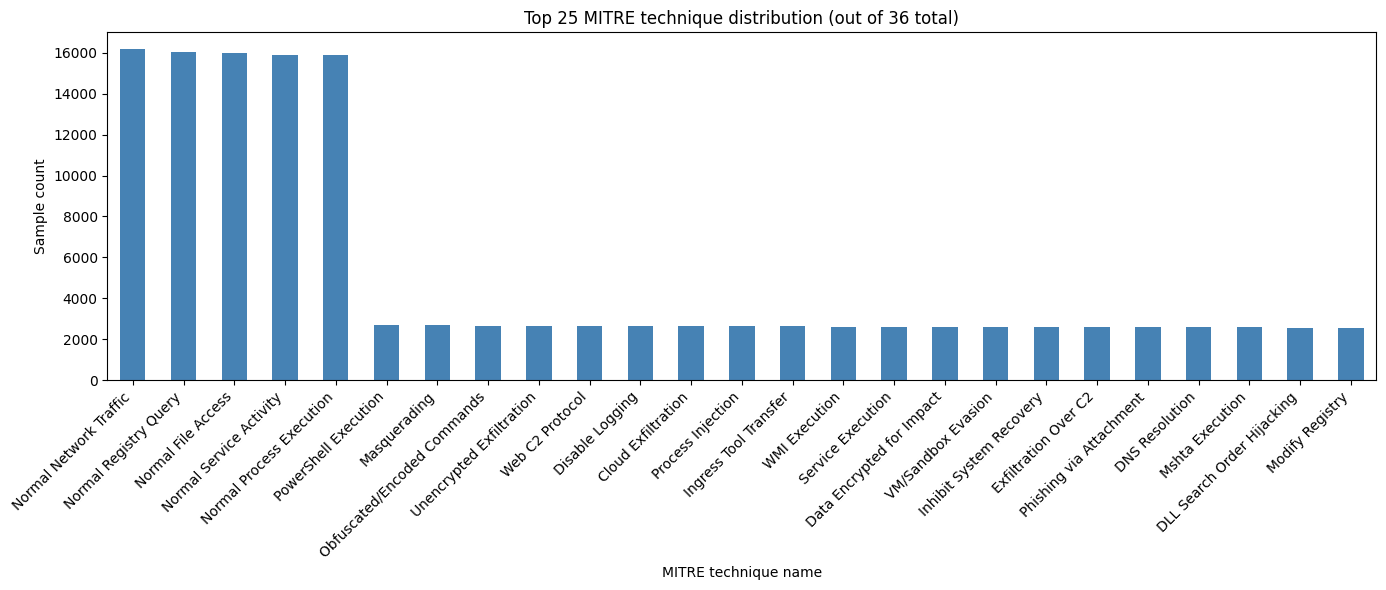

In [7]:
plt.figure(figsize=(14, 6))
top_n = 25
df['mitre_name'].value_counts().head(top_n).plot(kind='bar', color='steelblue')
plt.xlabel("MITRE technique name")
plt.ylabel("Sample count")
plt.title(f"Top {top_n} MITRE technique distribution (out of {df['mitre_name'].nunique()} total)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("mitre_class_distribution.png", dpi=150)
plt.show()

In [8]:
MIN_SAMPLES_PER_CLASS = 200

class_counts = df['mitre_name'].value_counts()
keep_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
df_filtered = df[df['mitre_name'].isin(keep_classes)].reset_index(drop=True)

print(f"Classes kept: {len(keep_classes)}")
print(f"Samples kept: {len(df_filtered):,} / {len(df):,}")
print(f"\nKept classes:")
for name, n in df_filtered['mitre_name'].value_counts().items():
    print(f"  {n:5,}  {name}")

Classes kept: 36
Samples kept: 160,000 / 160,000

Kept classes:
  16,188  Normal Network Traffic
  16,055  Normal Registry Query
  15,988  Normal File Access
  15,902  Normal Service Activity
  15,867  Normal Process Execution
  2,707  PowerShell Execution
  2,679  Masquerading
  2,668  Obfuscated/Encoded Commands
  2,641  Unencrypted Exfiltration
  2,636  Web C2 Protocol
  2,633  Disable Logging
  2,628  Cloud Exfiltration
  2,627  Process Injection
  2,624  Ingress Tool Transfer
  2,621  WMI Execution
  2,620  Service Execution
  2,609  Data Encrypted for Impact
  2,601  VM/Sandbox Evasion
  2,588  Inhibit System Recovery
  2,586  Exfiltration Over C2
  2,581  Phishing via Attachment
  2,579  DNS Resolution
  2,577  Mshta Execution
  2,568  DLL Search Order Hijacking
  2,558  Modify Registry
  2,555  Windows Command Shell
  2,545  Scheduled Task
  2,538  Create Account
  2,525  Credential Dumping
  2,525  Indicator Removal
  2,519  Automated Exfiltration
  2,508  Registry Run Keys
  

## 3. Train / Validation / Test Split

In [9]:
train_df, temp_df = train_test_split(
    df_filtered,
    test_size=0.30,
    stratify=df_filtered['mitre_name'],
    random_state=3407,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['mitre_name'],
    random_state=3407,
)
print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")


test_df.to_json("/content/mitre_test_set.jsonl", orient="records", lines=True)
print(f"\nSaved test set to /content/mitre_test_set.jsonl")

VALID_LABELS = sorted(df_filtered['mitre_name'].unique())
NUM_CLASSES = len(VALID_LABELS)
print(f"\nNumber of classes: {NUM_CLASSES}")

Train: 112,000  |  Val: 24,000  |  Test: 24,000

Saved test set to /content/mitre_test_set.jsonl

Number of classes: 36


## 4. Load the Base Model — Gemma 3 270M

In [10]:
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 768       # event fields + label fit well under 768 tokens
BASE_MODEL = "unsloth/gemma-3-270m-it"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = False,
)
print(f"Loaded {BASE_MODEL}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"VRAM after load: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.10: Fast Gemma3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

Loaded unsloth/gemma-3-270m-it
Parameters: 268,098,176
VRAM after load: 0.51 GB


## 5. Define the Prompts and the Evaluator

In [11]:
LABEL_LIST_STR = "\n".join(f"- {label}" for label in VALID_LABELS)

SYSTEM_PROMPT = (
    "You are a SOC analyst classifying security events according to the "
    "MITRE ATT&CK framework. For each event, respond with exactly one label "
    "from this set, in the format 'Label: <name>'.\n\n"
    f"Valid labels:\n{LABEL_LIST_STR}"
)


def format_event(row):
    """Render a single security event as a structured user message."""
    return (
        "Classify the following security event:\n\n"
        f"Event source : {row.get('event_type', 'unknown')}\n"
        f"Host         : {row.get('host', 'unknown')}\n"
        f"User         : {row.get('user', 'unknown')}\n"
        f"Parent       : {row.get('parent_process', 'unknown')}\n"
        f"Process      : {row.get('process_name', 'unknown')}\n"
        f"Command line : {row.get('commandline', '')}\n\n"
        "Respond with exactly: 'Label: <name>'"
    )


def build_messages(row):
    return [
        {"role": "user", "content": f"{SYSTEM_PROMPT}\n\n{format_event(row)}"},
    ]


_escaped_labels_sorted = sorted(VALID_LABELS, key=len, reverse=True)
_label_pattern = re.compile(
    r"\b(" + "|".join(re.escape(l) for l in _escaped_labels_sorted) + r")\b",
    flags=re.IGNORECASE,
)
_label_lookup = {l.lower(): l for l in VALID_LABELS}


def extract_label(response):
    """Pull a valid MITRE name out of the model's output."""
    # Strict format first
    m = re.search(r"Label\s*:\s*([^\n]+)", response, flags=re.IGNORECASE)
    if m:
        candidate = m.group(1).strip().strip(".,'\"")
        for label in _escaped_labels_sorted:
            if candidate.lower().startswith(label.lower()):
                return label

    m = _label_pattern.search(response)
    if m:
        return _label_lookup[m.group(1).lower()]

    return None


def predict(row):
    messages = build_messages(row)
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = 40,
            do_sample = False,
            pad_token_id = tokenizer.eos_token_id,
        )
    text = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    )
    return extract_label(text), text


def evaluate_on_df(eval_df, name="eval", sample_n=None):
    FastLanguageModel.for_inference(model)

    if sample_n is not None and sample_n < len(eval_df):
        eval_df = eval_df.sample(n=sample_n, random_state=3407).reset_index(drop=True)

    y_true, y_pred, raw_outputs = [], [], []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=f"Evaluating ({name})"):
        pred, raw = predict(row)
        if pred is None:
            pred = "UNKNOWN"
        y_pred.append(pred)
        y_true.append(row["mitre_name"])
        raw_outputs.append(raw)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', labels=VALID_LABELS, zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=VALID_LABELS, zero_division=0)
    parse_failures = sum(1 for p in y_pred if p == "UNKNOWN")

    metrics = {
        "accuracy":          float(acc),
        "f1_macro":          float(f1_macro),
        "f1_weighted":       float(f1_weighted),
        "parse_failure_pct": float(parse_failures / len(y_pred) * 100),
        "n_samples":         len(y_pred),
    }
    print(f"\n{name} metrics:")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"  {k:20s}: {v:.4f}")
        else:
            print(f"  {k:20s}: {v}")

    return metrics, list(zip(y_true, y_pred, raw_outputs))

## 6. Baseline Evaluation (no fine-tune)

In [12]:
print("=" * 60)
print("BASELINE - Gemma 3 270M with no MITRE fine-tuning")
print("=" * 60)
baseline_metrics, baseline_results = evaluate_on_df(test_df, name="baseline (test)", sample_n=500)

BASELINE - Gemma 3 270M with no MITRE fine-tuning


Evaluating (baseline (test)):   0%|          | 0/500 [00:00<?, ?it/s]

Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati


baseline (test) metrics:
  accuracy            : 0.0160
  f1_macro            : 0.0015
  f1_weighted         : 0.0011
  parse_failure_pct   : 43.4000
  n_samples           : 500


In [13]:
print("Baseline sample outputs:\n")
for truth, pred, raw in baseline_results[:5]:
    correct = '+' if truth == pred else '-'
    print(f"  [Truth: {truth!r:30s} | Predicted: {str(pred)!r:30s}] {correct}")
    print(f"  Raw response: {raw.strip()[:200]}")
    print()

Baseline sample outputs:

  [Truth: 'Normal Process Execution'     | Predicted: 'Automated Exfiltration'      ] -
  Raw response: Label: Automated Exfiltration

  [Truth: 'Normal Service Activity'      | Predicted: 'UNKNOWN'                     ] -
  Raw response: Label: EDR

  [Truth: 'System Discovery'             | Predicted: 'UNKNOWN'                     ] -
  Raw response: Label: Sysmon

  [Truth: 'Cloud Exfiltration'           | Predicted: 'UNKNOWN'                     ] -
  Raw response: Label: EDR

  [Truth: 'Obfuscated/Encoded Commands'  | Predicted: 'UNKNOWN'                     ] -
  Raw response: Label: Sysmon



## 7. Apply LoRA Adapters

In [14]:
torch.cuda.empty_cache(); gc.collect(); torch.cuda.empty_cache()
print(f"VRAM after cleanup: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

VRAM after cleanup: 0.54 GB


In [15]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.4f}%)")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Trainable: 3,796,992 / Total: 271,895,168 (1.3965%)


## 8. Format the Training Data

In [18]:
def format_for_training(row):
    user_msg = f"{SYSTEM_PROMPT}\n\n{format_event(row)}"
    assistant_msg = f"Label: {row['mitre_name']}"
    messages = [
        {"role": "user",      "content": user_msg},
        {"role": "assistant", "content": assistant_msg},
    ]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}


TARGET_PER_CLASS = 3000

train_subsample = (
    train_df.groupby('mitre_name')
            .apply(lambda x: x.sample(min(len(x), TARGET_PER_CLASS), random_state=3407))
            .reset_index(level=0) # Changed drop=True to keep 'mitre_name' as a column
            .reset_index(drop=True)
)
train_subsample = train_subsample.sample(frac=1, random_state=3407).reset_index(drop=True)

print(f"Training subsample: {len(train_subsample):,} examples")
print(f"Per-class counts (top 10):")
print(train_subsample['mitre_name'].value_counts().head(10))

train_records = [format_for_training(row) for _, row in train_subsample.iterrows()]
train_dataset = Dataset.from_list(train_records)

print(f"\nFirst training example:\n")
print(train_dataset[0]["text"][:1200])

Training subsample: 71,000 examples
Per-class counts (top 10):
mitre_name
Normal File Access             3000
Normal Service Activity        3000
Normal Process Execution       3000
Normal Network Traffic         3000
Normal Registry Query          3000
PowerShell Execution           1895
Masquerading                   1875
Obfuscated/Encoded Commands    1868
Unencrypted Exfiltration       1849
Web C2 Protocol                1845
Name: count, dtype: int64

First training example:

<bos><start_of_turn>user
You are a SOC analyst classifying security events according to the MITRE ATT&CK framework. For each event, respond with exactly one label from this set, in the format 'Label: <name>'.

Valid labels:
- Automated Exfiltration
- Cloud Exfiltration
- Create Account
- Credential Dumping
- DLL Search Order Hijacking
- DNS Resolution
- Data Encrypted for Impact
- Data from Local System
- Disable Logging
- Endpoint DoS
- Exfiltration Over C2
- Exploitation Remote Services
- Indicator Removal


## 9. Fine-Tune the Model

In [19]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 8,
        gradient_accumulation_steps = 4,    # effective batch = 32
        warmup_steps = 30,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 50,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        save_strategy = "no",
        report_to = "none",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<start_of_turn>user\n",
    response_part    = "<start_of_turn>model\n",
)

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/71000 [00:00<?, ? examples/s]

Map (num_proc=5):   0%|          | 0/71000 [00:00<?, ? examples/s]

Filter (num_proc=5):   0%|          | 0/71000 [00:00<?, ? examples/s]

In [20]:
print(f"VRAM before training: {torch.cuda.memory_reserved()/1024**3:.2f} GB")
trainer_stats = trainer.train()
print(f"\nPeak VRAM during training: {torch.cuda.max_memory_reserved()/1024**3:.2f} GB")
print(f"Training time: {trainer_stats.metrics['train_runtime']/60:.1f} minutes")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 71,000 | Num Epochs = 1 | Total steps = 2,219
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 3,796,992 of 271,895,168 (1.40% trained)


VRAM before training: 0.55 GB


Step,Training Loss
50,0.819237
100,0.117742
150,0.017127
200,0.000777
250,0.000399
300,0.000339
350,0.000287
400,0.000269
450,0.000352
500,0.000251



Peak VRAM during training: 7.22 GB
Training time: 134.0 minutes


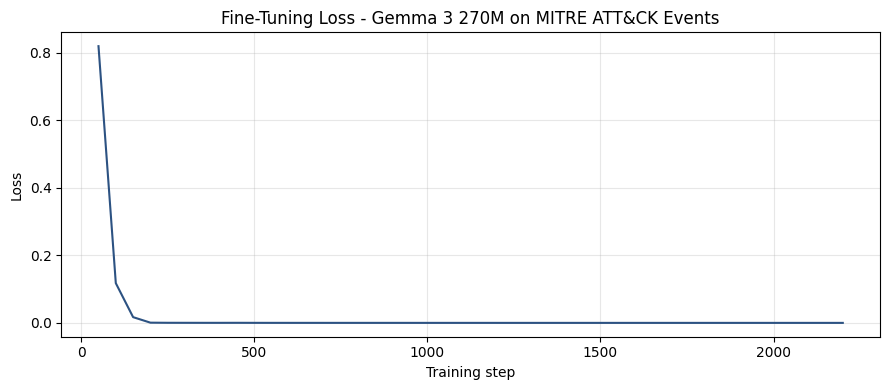

In [21]:
loss_history = trainer.state.log_history
losses = [(h["step"], h["loss"]) for h in loss_history if "loss" in h]
if losses:
    steps, vals = zip(*losses)
    plt.figure(figsize=(9, 4))
    plt.plot(steps, vals, linewidth=1.5, color="#2c5282")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Fine-Tuning Loss - Gemma 3 270M on MITRE ATT&CK Events")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("mitre_training_loss.png", dpi=150)
    plt.show()

## 10. Evaluation After Fine-Tuning

In [ ]:
print("=" * 60)
print("AFTER FINE-TUNING - Gemma 3 270M on MITRE ATT&CK Events")
print("=" * 60)
ft_metrics, ft_results = evaluate_on_df(test_df, name="fine-tuned (test)", sample_n=2000)

AFTER FINE-TUNING - Gemma 3 270M on MITRE ATT&CK Events


Evaluating (fine-tuned (test)):   0%|          | 0/2000 [00:00<?, ?it/s]

Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=40) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

## 11. Compare Baseline vs. Fine-Tuned

In [ ]:
rows = []
for metric in ["accuracy", "f1_macro", "f1_weighted", "parse_failure_pct"]:
    base_v = baseline_metrics[metric]
    ft_v   = ft_metrics[metric]
    delta  = ft_v - base_v
    rows.append({
        "Metric":     metric,
        "Baseline":   f"{base_v:.4f}",
        "Fine-tuned": f"{ft_v:.4f}",
        "Delta":      f"{delta:+.4f}",
    })

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))
df_compare.to_csv("mitre_before_after.csv", index=False)

In [ ]:
metric_names  = ["accuracy", "f1_macro", "f1_weighted"]
metric_labels = ["Accuracy", "F1 (macro)", "F1 (weighted)"]
base_vals = [baseline_metrics[m] for m in metric_names]
ft_vals   = [ft_metrics[m]       for m in metric_names]

x = np.arange(len(metric_names)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, base_vals, width, label="Baseline (no fine-tune)", color="#444")
b2 = ax.bar(x + width/2, ft_vals,   width, label="Fine-tuned on MITRE",     color="#2c5282")

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Gemma 3 270M on MITRE ATT&CK Events - Before vs After Fine-Tuning")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("mitre_before_after.png", dpi=150)
plt.show()

In [ ]:
y_true_ft = [r[0] for r in ft_results]
y_pred_ft = [r[1] for r in ft_results]

print("Per-class classification report:\n")
print(classification_report(y_true_ft, y_pred_ft, labels=VALID_LABELS, zero_division=0))

In [ ]:
cm = confusion_matrix(y_true_ft, y_pred_ft, labels=VALID_LABELS)

def shorten(name, max_len=28):
    return name if len(name) <= max_len else name[:max_len-1] + "..."
short_labels = [shorten(l) for l in VALID_LABELS]

plt.figure(figsize=(max(10, NUM_CLASSES*0.6), max(8, NUM_CLASSES*0.5)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels,
            cbar=True, annot_kws={"size": 8})
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Fine-Tuned Gemma on MITRE ATT&CK Test Set")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("mitre_confusion_matrix.png", dpi=150)
plt.show()

## 12. Save the Fine-Tuned Adapter

In [ ]:
model.save_pretrained("gemma-3-270m-mitre-lora")
tokenizer.save_pretrained("gemma-3-270m-mitre-lora")
print("Saved LoRA adapter to ./gemma-3-270m-mitre-lora/")

results_df = pd.DataFrame(ft_results, columns=["truth", "predicted", "raw_output"])
results_df["is_correct"] = (results_df["truth"] == results_df["predicted"]).astype(int)
results_df.to_csv("mitre_per_sample.csv", index=False)
print(f"Saved {len(results_df)} per-sample results to mitre_per_sample.csv")
print(f"Accuracy: {results_df['is_correct'].mean():.2%}")

## 13. Export to GGUF for Ollama Deployment

In [ ]:
print("Exporting to GGUF (Q4_K_M)...")
model.save_pretrained_gguf(
    "gemma-3-270m-mitre-gguf",
    tokenizer,
    quantization_method = "q4_k_m",
)
print("\nExport done. Files:")
!ls -lh gemma-3-270m-mitre-gguf/

In [ ]:
# Generate a Modelfile for Ollama
SYSTEM_PROMPT_ESCAPED = SYSTEM_PROMPT.replace('"', '\\"')

modelfile = f"""FROM ./gemma-3-270m-mitre-gguf/unsloth.Q4_K_M.gguf

TEMPLATE \"\"\"{{{{ if .System }}}}<start_of_turn>user
{{{{ .System }}}}

{{{{ end }}}}{{{{ range $i, $_ := .Messages }}}}<start_of_turn>{{{{ if eq .Role "user" }}}}user{{{{ else }}}}model{{{{ end }}}}
{{{{ .Content }}}}<end_of_turn>
{{{{ end }}}}<start_of_turn>model
\"\"\"

SYSTEM \"\"\"{SYSTEM_PROMPT_ESCAPED}\"\"\"

PARAMETER temperature 0
PARAMETER stop "<end_of_turn>"
"""

with open("Modelfile", "w") as f:
    f.write(modelfile)
print("Modelfile written. To import into Ollama on your local machine:")
print("  ollama create gemma-mitre -f Modelfile")
print("  ollama run gemma-mitre")

## 14. Discussion Points for the Dissertation

### What this experiment demonstrates

- **The same fine-tuning pattern transfers across domains.** The pipeline developed for spear-phishing detection (LoRA fine-tuning on Unsloth -> eval on held-out data -> GGUF export for Ollama) was reused for MITRE ATT&CK classification. One methodology, multiple operational use cases.
- **Smaller models can be enough for narrow classification.** Gemma 3 270M is roughly 11x smaller than the Llama-3.2-3B used for spear-phishing, yet achieves strong accuracy on a multi-class event classification task.
- **Context matters.** The model receives not just the command line but also the parent process, user, host and event source. A `powershell.exe` spawned by `explorer.exe` differs from one spawned by `svchost.exe` — these spawn-context features substantially help the classifier.
- **Human-readable labels are easier to learn than IDs.** Training the model to output `Masquerading` rather than `T1036.005` exploits the semantic content of the label and produces output that is directly useful to a SOC analyst.

### Agentic deployment scenario

The natural follow-up — discussed in Chapter 5 (Future Development) — is integration into an event-listening agent on each endpoint:

```
   Sysmon / Auditd / eBPF     ->     Gemma MITRE classifier (Ollama)
       (security events)                       |
                                       'Masquerading'? 'BENIGN'?
                                              |
                              Decision logic / Alert / Action
```

This is the dissertation's most operationally relevant contribution: an agent that **listens to system events and reacts based on MITRE classification**, running locally without sending sensitive event data to the cloud.

### Honest limitations

- The dataset is synthetic (timestamps and IPs are generated). Production deployment would need real captured events.
- The model classifies into a **closed set of MITRE techniques**. Novel attack patterns that do not map to an existing label will be misclassified.
- Single-event classification ignores **temporal context**: an isolated suspicious-looking command in a long benign session may be a false alarm, while the same command in a chain of post-exploitation actions is a true positive.
- Encoder-only models (BERT, SecBERT) would likely match Gemma 270M at lower inference cost, but they cannot be deployed via Ollama. Gemma's choice here is justified by deployment compatibility, not by raw classification superiority.

### Outputs available for the dissertation

| Artifact | Use |
|---|---|
| `mitre_before_after.csv` | Headline table for the MITRE subsection |
| `mitre_before_after.png` | Bar chart figure |
| `mitre_confusion_matrix.png` | Per-class confusion matrix |
| `mitre_training_loss.png` | Loss curve |
| `mitre_class_distribution.png` | Dataset overview |
| `mitre_per_sample.csv` | Per-sample appendix |
| `gemma-3-270m-mitre-lora/` | Saved LoRA adapter |
| `gemma-3-270m-mitre-gguf/` + `Modelfile` | Ollama deployment artifacts |
| `mitre_test_set.jsonl` | Frozen held-out test set (for the agent notebook) |

---

**End of notebook.**